# E-commerce Sales & Customer Analytics — Exploratory Analysis

Exploratory analysis of an e-commerce dataset (150k transactions, 7 countries, multiple sales channels and customer segments). Goal: gain insight into revenue, profit margin, discount behavior and customer satisfaction using pandas — grouping, merging, time series analysis and visualizations.

**Data:** `ecommerce_sales_customer_analytics_150k.csv`, `order_items.csv`, `customer_master.csv`, `product_catalog.csv`

## Loading and exploring the data

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
ecommerce = pd.read_csv('ecommerce_sales_customer_analytics_150k.csv')
customermaster = pd.read_csv('customer_master.csv')
order_items = pd.read_csv('order_items.csv')
productcatalog = pd.read_csv('product_catalog.csv')

In [3]:
order_items.head()

,order_id,product_id,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,product_cost,profit
0,ORD-301242,PROD-000738,2,244.40,0.339607,166.00,488.80,22.60,6.48,351.88,173.28,172.12
1,ORD-301242,PROD-000181,3,287.13,0.362076,311.89,861.39,38.47,5.55,593.52,415.05,172.92
2,ORD-773460,PROD-000973,4,754.80,0.468300,1413.89,3019.20,305.01,9.00,1919.32,1976.16,-65.84
3,ORD-773460,PROD-000268,4,31.36,0.336182,42.17,125.44,15.82,0.00,99.09,55.72,43.37
4,ORD-449374,PROD-001040,3,6.31,0.089678,1.70,18.93,1.21,0.98,19.42,5.91,12.53


In [4]:
order_items.dtypes

order_id                   str
product_id                 str
quantity                 int64
unit_price             float64
discount_percentage    float64
discount_amount        float64
gross_sales            float64
tax_amount             float64
shipping_cost          float64
net_sales              float64
product_cost           float64
profit                 float64
dtype: object

In [5]:
order_items.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price',
       'discount_percentage', 'discount_amount', 'gross_sales', 'tax_amount',
       'shipping_cost', 'net_sales', 'product_cost', 'profit'],
      dtype='str')

In [6]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 397569 entries, 0 to 397568
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             397569 non-null  str    
 1   product_id           397569 non-null  str    
 2   quantity             397569 non-null  int64  
 3   unit_price           397569 non-null  float64
 4   discount_percentage  397569 non-null  float64
 5   discount_amount      397569 non-null  float64
 6   gross_sales          397569 non-null  float64
 7   tax_amount           397569 non-null  float64
 8   shipping_cost        397569 non-null  float64
 9   net_sales            397569 non-null  float64
 10  product_cost         397569 non-null  float64
 11  profit               397569 non-null  float64
dtypes: float64(9), int64(1), str(2)
memory usage: 36.4 MB


In [7]:
order_items.describe()

,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,product_cost,profit
count,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000,397569.000000
mean,2.118792,245.189134,0.147059,89.667873,519.013550,46.183642,8.409010,483.938328,267.520046,208.009273
std,1.196276,251.035134,0.129986,190.637796,676.800478,71.072019,6.777155,615.430188,394.773555,266.477677
min,1.000000,6.310000,0.000000,0.000000,6.310000,0.260000,0.000000,5.350000,1.970000,-1260.280000
25%,1.000000,74.360000,0.048137,5.940000,122.000000,9.560000,3.370000,124.280000,52.960000,53.730000
50%,2.000000,164.970000,0.124253,26.340000,280.190000,22.550000,5.870000,271.100000,127.100000,121.660000
75%,3.000000,310.790000,0.199499,86.030000,643.560000,52.340000,12.460000,595.240000,314.310000,259.660000
max,5.000000,1482.950000,0.600000,3857.670000,7414.750000,1482.950000,36.460000,8897.700000,4968.150000,4045.100000


## 1. How many unique customers (customer_id) are in the dataset, and how many unique countries?

In [8]:
# Unique customers
customermaster['customer_id'].nunique()

25000

In [9]:
# Unique countries 
customermaster['customer_country'].nunique()

7

## 2. Filter all order_items with order_status == "Completed" and calculate the average net_sales.

In [10]:
ecommerce.head()

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,...,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,...,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,...,97.30,29.79,13.05,468.35,257.73,197.57,42.18,6159.44,True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,...,53.34,34.39,20.85,546.52,277.84,247.83,45.35,5638.30,True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,...,133.63,421.35,23.03,2785.27,1231.88,1530.36,54.94,13240.10,True,8


In [11]:
completed = ecommerce[ecommerce['order_status'] == 'Completed'] 
completed.head()

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,...,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,...,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,...,97.30,29.79,13.05,468.35,257.73,197.57,42.18,6159.44,True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,...,53.34,34.39,20.85,546.52,277.84,247.83,45.35,5638.30,True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,...,133.63,421.35,23.03,2785.27,1231.88,1530.36,54.94,13240.10,True,8


In [12]:
ecommerce.columns

Index(['order_id', 'order_date', 'order_time', 'order_status', 'sales_channel',
       'customer_id', 'customer_name', 'customer_age', 'gender',
       'customer_segment', 'customer_type', 'customer_city', 'customer_state',
       'customer_country', 'region', 'customer_postal_code', 'payment_method',
       'payment_status', 'currency', 'shipping_method', 'warehouse',
       'delivery_days', 'estimated_delivery_days', 'delivery_status',
       'return_status', 'return_reason', 'customer_rating', 'review_sentiment',
       'customer_review', 'marketing_channel', 'campaign_name', 'coupon_code',
       'loyalty_points_earned', 'loyalty_points_redeemed', 'quantity',
       'gross_sales', 'discount_amount', 'tax_amount', 'shipping_cost',
       'net_sales', 'product_cost', 'profit', 'profit_margin_percentage',
       'customer_lifetime_value', 'is_repeat_customer',
       'customer_order_count'],
      dtype='str')

In [13]:
completed['net_sales'].mean()

np.float64(1269.7878503685308)

## 3. Create a new order_date column of type datetime, and print the earliest and latest order date.

In [14]:
ecommerce.dtypes

order_id                        str
order_date                      str
order_time                      str
order_status                    str
sales_channel                   str
customer_id                     str
customer_name                   str
customer_age                  int64
gender                          str
customer_segment                str
customer_type                   str
customer_city                   str
customer_state                  str
customer_country                str
region                          str
customer_postal_code          int64
payment_method                  str
payment_status                  str
currency                        str
shipping_method                 str
warehouse                       str
delivery_days               float64
estimated_delivery_days     float64
delivery_status                 str
return_status                   str
return_reason                   str
customer_rating             float64
review_sentiment            

In [15]:
ecommerce['order_date'] = pd.to_datetime(ecommerce['order_date'])

In [16]:
ecommerce['order_date'].min()

Timestamp('2021-01-01 00:00:00')

In [17]:
ecommerce['order_date'].max()

Timestamp('2025-12-31 00:00:00')

## 4. Group by customer_segment and calculate per segment: number of order_items, total revenue (net_sales) and average profit_margin_percentage. Sort by revenue, descending.

In [18]:
grouped_segment = ecommerce.groupby(['customer_segment'])
grouped_segment.agg({
    'order_id' : 'count',
    'net_sales' : 'sum' ,
    'profit_margin_percentage' : 'mean'
}).sort_values('net_sales', ascending=True)

,order_id,net_sales,profit_margin_percentage
customer_segment,,,
Business,13777,17760296.90,45.992864
VIP,13957,17903164.81,43.197068
Premium,34746,44269794.13,43.224458
Consumer,75636,97201007.90,46.088015


## 5. Merge order_items.csv with product_catalog.csv on product_id, and determine which product_category generates the highest total profit.

In [19]:
merged = pd.merge(order_items, productcatalog, on='product_id')
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 397569 entries, 0 to 397568
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             397569 non-null  str    
 1   product_id           397569 non-null  str    
 2   quantity             397569 non-null  int64  
 3   unit_price_x         397569 non-null  float64
 4   discount_percentage  397569 non-null  float64
 5   discount_amount      397569 non-null  float64
 6   gross_sales          397569 non-null  float64
 7   tax_amount           397569 non-null  float64
 8   shipping_cost        397569 non-null  float64
 9   net_sales            397569 non-null  float64
 10  product_cost_x       397569 non-null  float64
 11  profit               397569 non-null  float64
 12  product_name         397569 non-null  str    
 13  product_category     397569 non-null  str    
 14  product_subcategory  397569 non-null  str    
 15  brand                397569 

In [20]:
grouped_category = merged.groupby(['product_category'])
grouped_category.agg({
    'profit' : 'sum'
}).sort_values('profit', ascending=False)

,profit
product_category,
Electronics,14103982.74
Jewelry,10391635.32
Home Appliances,10288878.45
Sports & Outdoors,7230037.31
Automotive,6477194.28
Home & Kitchen,5203824.25
Baby & Kids,4818148.07
Office Supplies,4585377.04
Health & Wellness,4263304.41


## 6. Resample order_items by month (order_date) and plot revenue per month as a line chart.

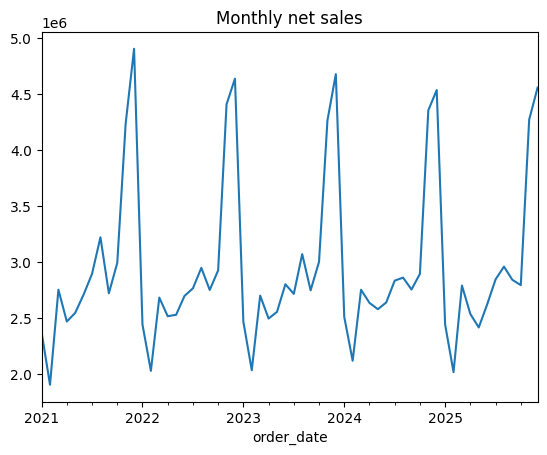

In [21]:
order_items_date = ecommerce.set_index('order_date')
monthly = order_items_date.resample('MS')['net_sales'].sum() 
monthly.plot(title='Monthly net sales')
plt.show()

## 7. Group by customer_country and calculate the number of order_items and average customer_rating per country.

In [22]:
ecommerce.head()

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,...,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,...,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,...,97.30,29.79,13.05,468.35,257.73,197.57,42.18,6159.44,True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,...,53.34,34.39,20.85,546.52,277.84,247.83,45.35,5638.30,True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,...,133.63,421.35,23.03,2785.27,1231.88,1530.36,54.94,13240.10,True,8


In [23]:
ecommerce.groupby(ecommerce['customer_country']).agg({
    'order_id' : 'count',
    'customer_rating' : 'mean'
})

,order_id,customer_rating
customer_country,,
Australia,6794,3.674279
Canada,7015,3.672349
Germany,11593,3.674417
India,5707,3.667380
UAE,4172,3.681997
UK,20235,3.675583
USA,82600,3.678759


## 8. Group by both customer_segment and sales_channel and calculate total net_sales per combination.

In [24]:
segment_channel = ecommerce.groupby([ecommerce['customer_segment'], ecommerce['sales_channel']]).agg({
    'net_sales' : 'sum'
})
segment_channel

net_sales
customer_segment sales_channel             
Business         Marketplace     2738441.90
                 Mobile App      7205034.67
                 Social Media    1794598.27
                 Website         6022222.06
Consumer         Marketplace    14451548.86
                 Mobile App     38969343.25
                 Social Media    9867191.59
                 Website        33912924.20
Premium          Marketplace     6851534.93
                 Mobile App     17562662.69
                 Social Media    4299804.32
                 Website        15555792.19
VIP              Marketplace     2654664.53
                 Mobile App      7097741.92
                 Social Media    1786960.73
                 Website         6363797.63

## 9. Turn that combination into a clearer table.

In [25]:
pd.pivot_table(segment_channel, values='net_sales', index='customer_segment', columns='sales_channel')

sales_channel,Marketplace,Mobile App,Social Media,Website
customer_segment,,,,
Business,2738441.90,7205034.67,1794598.27,6022222.06
Consumer,14451548.86,38969343.25,9867191.59,33912924.20
Premium,6851534.93,17562662.69,4299804.32,15555792.19
VIP,2654664.53,7097741.92,1786960.73,6363797.63


## 10. Is there a relationship between customer_rating and profit_margin_percentage?

In [26]:
ecommerce[['customer_rating', 'profit_margin_percentage']].corr()

,customer_rating,profit_margin_percentage
customer_rating,1.000000,-0.040079
profit_margin_percentage,-0.040079,1.000000


## 11. Now create a bar chart of the average profit_margin_percentage per product_category.

In [27]:
merged.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price_x',
       'discount_percentage', 'discount_amount', 'gross_sales', 'tax_amount',
       'shipping_cost', 'net_sales', 'product_cost_x', 'profit',
       'product_name', 'product_category', 'product_subcategory', 'brand',
       'supplier', 'unit_price_y', 'product_cost_y', 'product_rating'],
      dtype='str')

In [28]:
merged['profit_margin_percentage'] = (merged['profit'] / merged['net_sales']) * 100
merged['profit_margin_percentage'] = merged['profit_margin_percentage'].round(2)

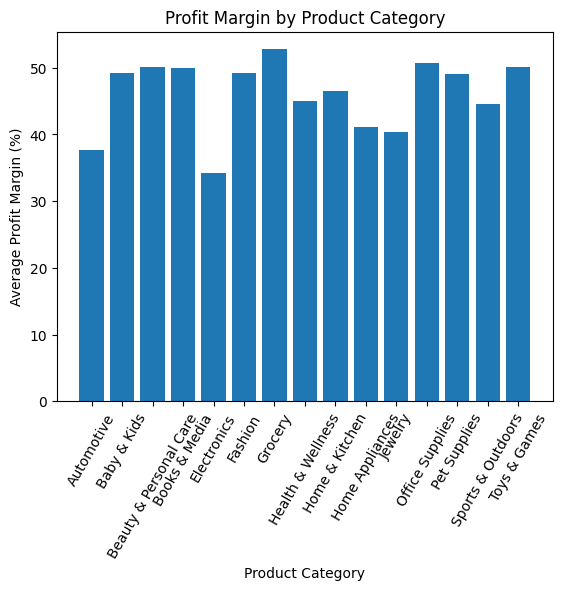

In [29]:
profit_margin_per_category = merged.groupby('product_category')['profit_margin_percentage'].mean()
x, y = profit_margin_per_category.index, profit_margin_per_category.values
plt.bar(x, y)
plt.xlabel('Product Category')
plt.ylabel('Average Profit Margin (%)')
plt.title('Profit Margin by Product Category')
plt.xticks(rotation=60)
plt.show()

## 12. Create a new discount_pct column that calculates the discount percentage per order line.

In [30]:
ecommerce['discount_pct'] = (ecommerce['discount_amount'] / ecommerce['gross_sales']) * 100

## 13. Categorize discount_pct into discount categories (None / Low / Average / High) and count how often each category occurs.

In [31]:
def discount_category(pct):
    if pct == 0:
        return 'No discount'
    elif pct <= 10:
        return 'Low discount'
    elif pct <= 20:
        return 'Average discount'
    else:
        return 'High discount'


In [32]:
ecommerce['discount_category'] = ecommerce['discount_pct'].apply(discount_category)
ecommerce.head()

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count,discount_pct,discount_category
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,...,12.03,945.40,588.33,345.04,36.50,12459.68,True,11,35.394278,High discount
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,...,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11,46.302915,High discount
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,...,13.05,468.35,257.73,197.57,42.18,6159.44,True,6,18.610968,Average discount
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,...,20.85,546.52,277.84,247.83,45.35,5638.30,True,7,9.793985,Low discount
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,...,23.03,2785.27,1231.88,1530.36,54.94,13240.10,True,8,5.400239,Low discount


In [33]:
ecommerce['discount_category'].value_counts()

discount_category
Average discount    49198
High discount       36023
Low discount        35031
No discount         17864
Name: count, dtype: int64

## 14. Count how often each payment method occurs (payment_method).

In [34]:
ecommerce['payment_method'].value_counts()

payment_method
Credit Card          41460
Debit Card           27635
PayPal               20750
Digital Wallet       16382
Cash on Delivery     13863
Buy Now Pay Later    11061
Bank Transfer         6965
Name: count, dtype: int64

## Conclusion

This analysis of the e-commerce dataset reveals several clear patterns. Discounts are widely applied, but heavy discounts (>20%) are not the norm — the majority of orders fall into the average discount category. Profit margin varies significantly by product category: Books & Media hovers around 35%, while Grocery exceeds 50% margin, suggesting there is room to optimize the product mix toward higher-margin categories. In terms of revenue, Mobile App and Website clearly stand out compared to Marketplace and Social Media, suggesting further investment in these two channels would yield the most return. Notably, customer satisfaction (customer rating) is remarkably consistent across all countries, pointing to consistent product quality and customer experience worldwide. Finally, the time series analysis shows a clear spike in orders at the end of the year, followed by a sharp decline — this warrants further investigation to determine whether it can be prevented or better leveraged in planning.